In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
cleaned_df = pd.read_csv("Data/Japan_Visitor_Data.csv")
cleaned_df["Date"] = pd.to_datetime(cleaned_df["Date"])
cleaned_df = cleaned_df[["Year", "Month", "Date", "Daily Visitors"]]
cleaned_df

,Year,Month,Date,Daily Visitors
0,1996,Jan,1996-01-01,8906.000000
1,1996,Feb,1996-02-01,9781.620690
2,1996,Mar,1996-03-01,10022.645161
3,1996,Apr,1996-04-01,10976.766667
4,1996,May,1996-05-01,10521.161290
...,...,...,...,...
356,2025,Sep,2025-09-01,108907.600000
357,2025,Oct,2025-10-01,125694.322581
358,2025,Nov,2025-11-01,117273.166667
359,2025,Dec,2025-12-01,116700.000000


In [128]:
# using the last 24 months (two years)
cutoff = 24
x = cleaned_df.copy().iloc[0:-cutoff]
y = cleaned_df.copy().iloc[-cutoff:]
print(len(x) - 12)


325


In [17]:
# Box-Cox Transforming Naive Data
def box_cox (df, lambo):
    if lambo == 0:
        df["Daily_Arrivals_Cox"] = np.log(df["Daily Visitors"])
        return df
    else:
        df["Daily_Arrivals_Cox"] = (df["Daily Visitors"]**lambo - 1)/lambo
        return df

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_3442/3006162029.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


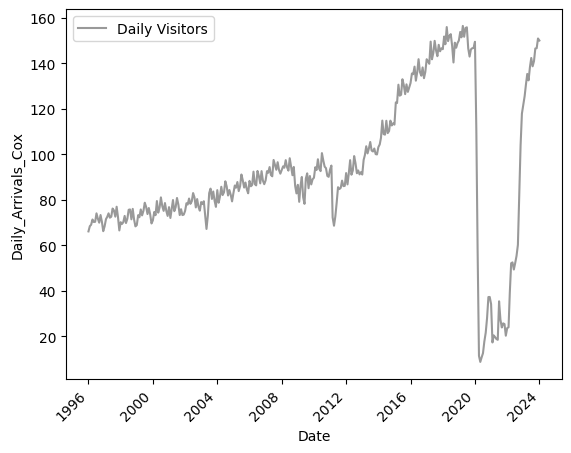

In [24]:
# Simple Graph

def standard_graph(df, column):
    sns.lineplot(data = df, x = "Date", y = column, 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
    current_values = plt.gca().get_yticks()
    plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
    plt.xticks(rotation=45, ha="right")

log_df_naive = box_cox(x, lambo = .35) # edit the lambo parameter to test out different lambdas
standard_graph(log_df_naive, "Daily_Arrivals_Cox")


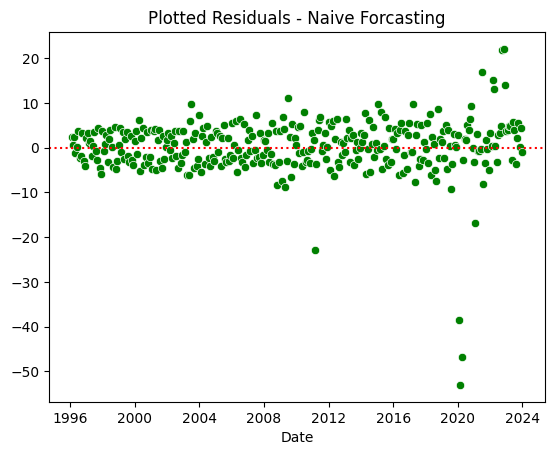

In [25]:
# Testing Residuals for the naive method
y_hat = log_df_naive["Daily_Arrivals_Cox"].to_numpy()[0:-1]
y_resid = log_df_naive["Daily_Arrivals_Cox"].to_numpy()[1:]
resid = y_resid - y_hat
sns.scatterplot(x = log_df_naive["Date"][1:], y = resid, color = "g")
plt.title(label = "Plotted Residuals - Naive Forcasting")
plt.axhline(y = 0, color='red', linestyle=':') 
plt.show()


Nice, let's use computer software to find the optimal lambda

In [26]:
from scipy import stats
placeholder, best_lambda = stats.boxcox(x["Daily Visitors"])
print(best_lambda)

0.3452013864611274


After setting the lambda to 0.3, this works a lot better

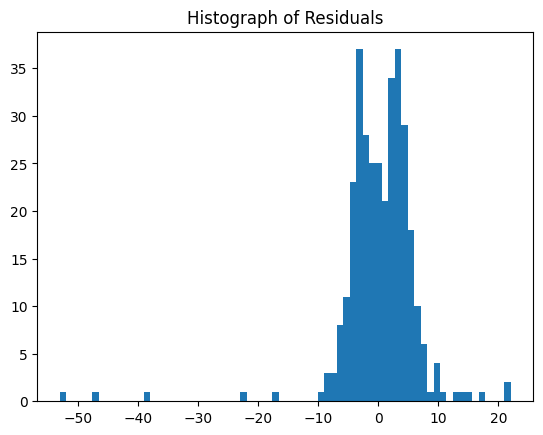

In [27]:
plt.hist(x = resid, bins = 70)
plt.title(label = "Histograph of Residuals")
plt.show()

Some weird bimodal stuff going on here, probably because the shifting month means the naive method is either higher or lower than the previous estimate

Looks pretty, good, maybe a bit too lage of a tail to the left (however, it somehow balances out the stuff on the right)

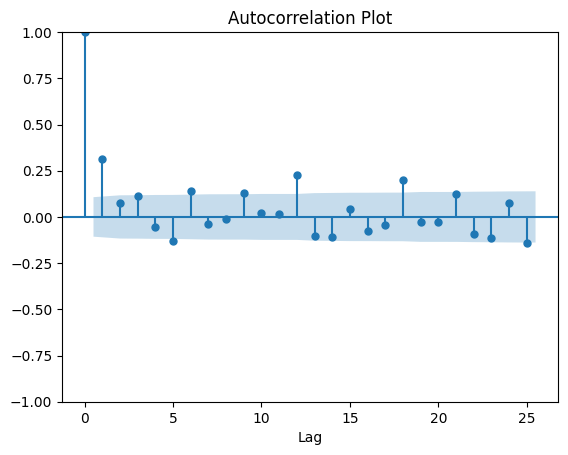

In [28]:
from statsmodels.graphics.tsaplots import plot_acf

# 'data' should be a 1D array or pandas Series
plot_acf(resid, lags = 25)
plt.title(label = "Autocorrelation Plot")
plt.xlabel(xlabel = "Lag")
plt.show()

Looks pretty good, outside of first part (correlation of residual with itself), the autocorrelation appears to be pretty random
## Next Step: Calculating Standard Deviation of residuals
We now want to calcualte the standard deviation of the residuals

$\hat{\sigma} = \sqrt{\frac{1}{T-K-M}\sum{e_t^2}}$

Where T is number of time steps, K is number of parameters estimated in the forecasting method, and M is the number of missing values in the residuals (M = 1 for naive forecast because we don't forecast first observation)

"If a transformation has been used, then the prediction interval is first computed on the transformed scale, and the end points are back-transformed to give a prediction interval on the original scale. This approach preserves the probability coverage of the prediction interval, although it will no longer be symmetric around the point forecast."

In [31]:
import numpy as np
std = np.sqrt((1/(len(x)-1-1))* np.sum(np.square(resid)))
std

6.501188279201797

In [47]:
# Prediction interval
range = std*1.96

lower, upper = x["Daily_Arrivals_Cox"].iloc[-1] - range, x["Daily_Arrivals_Cox"].iloc[-1] + range
print(lower, upper)



137.25657832279603 162.74123637726706
332    72814.733333
333    81181.387097
334    81363.000000
335    88197.258065
336    86725.096774
Name: Daily Visitors, dtype: float64


In [49]:
def unbox(val, lambo):
    return (val * lambo + 1) ** (1/lambo)

lower_untransform, upper_untransform = unbox(lower, lambo = 0.35), unbox(upper, lambo = 0.35)
print("95% confidence interval")
print((lower_untransform, upper_untransform))
median = unbox(x["Daily_Arrivals_Cox"].iloc[-1], lambo = 0.35)
print(median)

95% confidence interval
(67629.96711667175, 109017.82256726823)
86725.09677419347


what's better - naive, seasonal naive, mean, or drift? let's find out (this might be hard)

I'm going to use cross validation, starting on the 13th observation (because otherwise the seasonal version won't work)

2978.010417142368
5051.859657469367
35.37342352410472


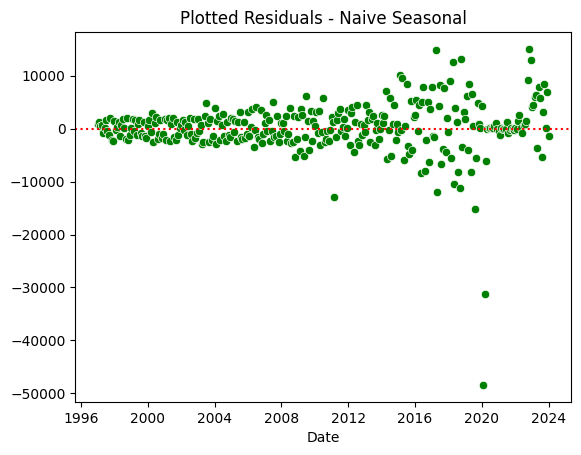

In [133]:
# Naive residuals
y_hat = x["Daily Visitors"].to_numpy()[11:-1]
y_resid = x["Daily Visitors"].to_numpy()[12:]
resid = (y_resid - y_hat) # removing first 11 to make it comparable to others
naive_mae = np.mean(np.abs(resid))
naive_rsme = np.sqrt(np.mean(np.square(resid)))
naive_percent = np.mean(np.abs((100*resid)/y_resid))
print(naive_mae)
print(naive_rsme)
print(naive_percent)

sns.scatterplot(x = x["Date"][12:], y = resid, color = "g")
plt.title(label = "Plotted Residuals - Naive Seasonal")
plt.axhline(y = 0, color='red', linestyle=':') 
plt.show()

9886.006236795462
21105.436006839227
1696.3404931052773


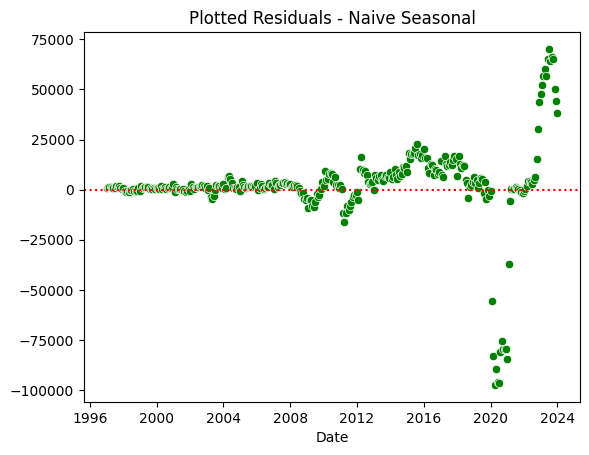

325


In [125]:
# seasonally naive residuals
y_hat = x["Daily Visitors"].to_numpy()[:-12]
y_resid = x["Daily Visitors"].to_numpy()[12:]
resid = (y_resid - y_hat)
naive_mae = np.mean(np.abs(resid))
naive_rsme = np.sqrt(np.mean(np.square(resid)))
naive_percent = np.mean(np.abs((100*resid)/y_resid))
print(naive_mae)
print(naive_rsme)
print(naive_percent)

sns.scatterplot(x = x["Date"][12:], y = resid, color = "g")
plt.title(label = "Plotted Residuals - Naive Seasonal")
plt.axhline(y = 0, color='red', linestyle=':') 
plt.show()


MAE: 17368.774774635094
RSME: 26165.85403062641
Percent error: 811.1107644213312


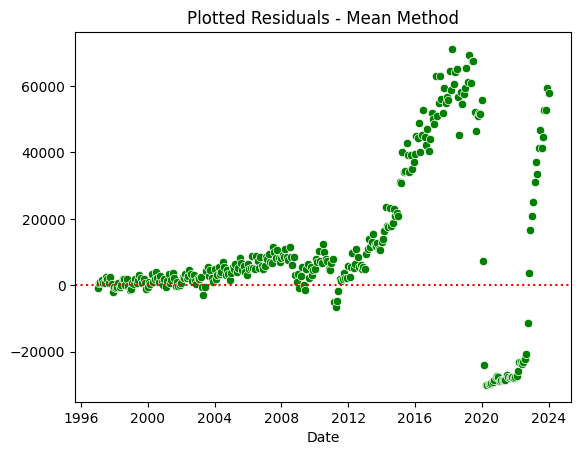

[10481.60584600173, 10425.075371495393, 10469.503661286539, 10535.467933329803, 10637.15743749669, 10677.402445917187, 10723.23193966253, 10850.718883415437, 10945.370036018858, 10972.387335890977, 11088.356533233176, 11102.535234686806, 11017.605675177003, 10996.144028815084, 10964.413214519998, 10946.83638100731, 10972.370795971334, 10950.27235918033, 10955.774391652096, 11017.87220003793, 11078.396355077071, 11076.425758458576, 11135.041319642432, 11130.209662890744, 11091.77910773876, 11061.193970563607, 11080.692625473586, 11088.972632595438, 11135.729150113882, 11150.88760514651, 11186.909328833499, 11261.509336940146, 11312.086470778015, 11327.802326982948, 11369.723875274343, 11381.852445303968, 11358.385089252608, 11347.529962348835, 11369.283501032893, 11377.658713852614, 11442.849892432372, 11458.872201217882, 11493.670246874342, 11568.47682889598, 11605.768429301641, 11624.236234635531, 11670.682662180747, 11686.947927793504, 11686.39126878189, 11715.059629790754, 11707.836

In [141]:
# Mean method
y_resid = x["Daily Visitors"].to_numpy()[12:]
y_hat = []
for i in np.arange(12, len(x)):
    y_hat.append(np.mean(x["Daily Visitors"].iloc[:i]))
resid = (y_resid - y_hat)
naive_mae = np.mean(np.abs(resid))
naive_rsme = np.sqrt(np.mean(np.square(resid)))
naive_percent = np.mean(np.abs((100*resid)/y_resid))
print("MAE: " + str(naive_mae))
print("RSME: " + str(naive_rsme))
print("Percent error: " + str(naive_percent))

sns.scatterplot(x = x["Date"][12:], y = resid, color = "g")
plt.title(label = "Plotted Residuals - Mean Method")
plt.axhline(y = 0, color='red', linestyle=':') 
plt.show()
print(y_hat)

[8942.728494623654, 9811.379652605458, 11200.005102040817, 11629.16559139785, 12366.03125, 11463.400379506638, 11646.574074074075, 13368.614601018677, 12935.629032258064, 11636.863492063492, 13733.605571847507, 11523.53043478261, 9070.818548387098, 10544.067096774193, 10219.802197802197, 10548.499402628437, 11760.221428571427, 10380.671857619576, 11188.977777777778, 13009.026014568159, 13081.165322580644, 11077.226262626265, 13191.806451612903, 11024.788571428571, 9770.062724014337, 9988.619006102877, 11878.357142857143, 11467.654259718778, 13060.564166666667, 11826.767899291897, 12753.271428571428, 14522.35408852213, 13591.014662756597, 12088.484444444444, 13350.762973352033, 12004.314893617022, 10283.532258064517, 10865.677419354839, 12505.79103448276, 11853.094244149273, 14880.323076923078, 12355.919659160072, 13420.04012345679, 15729.887390029324, 13741.642281105991, 12724.265497076023, 14411.441601779756, 12693.457627118645, 11699.340860215056, 13509.409836065573, 11305.3346774193

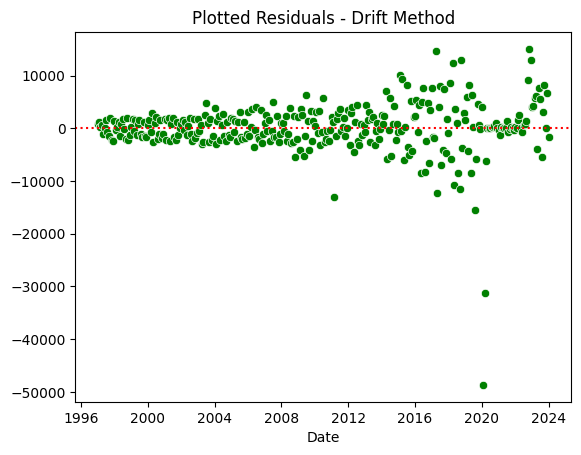

In [142]:
# Drift method
y_resid = x["Daily Visitors"].to_numpy()[12:]
y_hat = []
for i in np.arange(12, len(x)):
    y_hat.append(x["Daily Visitors"].iloc[i-1] + (x["Daily Visitors"].iloc[i-1] - x["Daily Visitors"].iloc[0])/i  )
print(y_hat)
resid = (y_resid - y_hat)
naive_mae = np.mean(np.abs(resid))
naive_rsme = np.sqrt(np.mean(np.square(resid)))
naive_percent = np.mean(np.abs((100*resid)/y_resid))
print("MAE: " + str(naive_mae))
print("RSME: " + str(naive_rsme))
print("Percent error: " + str(naive_percent))

sns.scatterplot(x = x["Date"][12:], y = resid, color = "g")
plt.title(label = "Plotted Residuals - Drift Method")
plt.axhline(y = 0, color='red', linestyle=':') 
plt.show()

It looks like the naive method is (barely) the best one for single-point predictions excactly one month into the future.